# AUC Detection Per Layer

Answers the question: **which layer of the judge model first "knows" that the prediction is wrong?**

For every `SelfAttention.o` layer (in forward-pass order), we extract the last-token
activation vector for each scan, reduce with PCA, and score a cross-validated XGBoost
classifier. The resulting AUC-vs-layer curve shows where in the network the
hallucination signal emerges and where it peaks.

Data loading mirrors `pca_dimensions_classifier.ipynb`.

## Cell 1 — Imports

In [1]:
import sys, os, re

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import optuna
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from neuralsignal.backend.ns_backend import NSBackend

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Imports OK")

Imports OK


## Cell 2 — Config

In [2]:
APPLICATION_NAME     = "redis"
SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

GROUP_SIZE   = 50          # total scans per class
HALF         = GROUP_SIZE // 2   # loaded equally from ground_truth=0 and ground_truth=1
K_COMPONENTS = 10          # PCA dims applied at every layer (keeps comparison fair)
CV_FOLDS     = 5           # stratified k-fold
RANDOM_STATE = 42

# Each class is loaded from two sub-filters (gt=0 and gt=1) in equal halves,
# so the classifier cannot exploit ground_truth value as a spurious feature.
FILTER_CORRECT_GT0      = {"ground_truth": "0", "decoded_output": {"$regex": "^Fal"}}
FILTER_CORRECT_GT1      = {"ground_truth": "1", "decoded_output": {"$regex": "^True"}}
FILTER_HALLUCINATED_GT0 = {"ground_truth": "0", "decoded_output": {"$regex": "^True"}}
FILTER_HALLUCINATED_GT1 = {"ground_truth": "1", "decoded_output": {"$regex": "^Fal"}}

## Cell 3 — Connect to backend & load scans

In [3]:
import tempfile
from neuralsignal.core.modules.neuralsignal_config import sdk_config

backend_cfg = sdk_config.get_backend_config()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def load_group(be, filter_a, filter_b, n_each):
    """Load n_each scans from filter_a and n_each from filter_b, combined."""
    scans = []
    for f in [filter_a, filter_b]:
        cursor = be.query(f).limit(n_each)
        for doc in cursor:
            try:
                scans.append(be.deserialize_scan(doc))
            except Exception as e:
                print(f"  skipping {doc.get('_id')}: {e}")
    return scans

print(f"Loading correct group ({HALF} gt=0 + {HALF} gt=1) ...")
group_correct = load_group(be, FILTER_CORRECT_GT0, FILTER_CORRECT_GT1, HALF)
print(f"  loaded {len(group_correct)} scans")

print(f"Loading hallucinated group ({HALF} gt=0 + {HALF} gt=1) ...")
group_hallucinated = load_group(be, FILTER_HALLUCINATED_GT0, FILTER_HALLUCINATED_GT1, HALF)
print(f"  loaded {len(group_hallucinated)} scans")

Loading correct group (25 gt=0 + 25 gt=1) ...
  loaded 50 scans
Loading hallucinated group (25 gt=0 + 25 gt=1) ...
  loaded 50 scans


## Cell 4 — Discover SelfAttention.o layers

Inspects the first scan to find all `SelfAttention.o` layers in forward-pass order
and builds short display labels from the block index embedded in each layer name.

In [4]:
def get_sa_layers(scan):
    """Return [(layer_id, full_name, short_label), ...] in forward-pass order."""
    lid_to_name = scan["layer_id_to_name"]
    enc_idx = dec_idx = 0
    rows = []
    for lid in scan["layer_order"]:
        name = lid_to_name[lid]
        if "SelfAttention.o" not in name:
            continue
        is_enc = "encoder" in name.lower()
        # Try to pull a numeric block index from the name
        m = re.search(r'\.(\d+)\.', name)
        if m:
            label = f"{'enc' if is_enc else 'dec'}.{m.group(1)}"
        else:
            # Fall back to a sequential counter per stack
            if is_enc:
                label = f"enc.{enc_idx}"
                enc_idx += 1
            else:
                label = f"dec.{dec_idx}"
                dec_idx += 1
        rows.append((lid, name, label))
    return rows

sa_layers = get_sa_layers(group_correct[0])
print(f"Found {len(sa_layers)} SelfAttention.o layers:\n")
for i, (lid, name, label) in enumerate(sa_layers):
    print(f"  [{i:>2}] {label:<10}  {name}")

Found 48 SelfAttention.o layers:

  [ 0] enc.0       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 1] enc.1       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 2] enc.2       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 3] enc.3       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 4] enc.4       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 5] enc.5       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 6] enc.6       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 7] enc.7       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 8] enc.8       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [ 9] enc.9       encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [10] enc.10      encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [11] enc.11      encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [12] enc.12      encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
  [13] enc.13      encoder.T5B

## Cell 5 — Per-layer AUC sweep

For each layer, extracts the last-token activation vector for every scan,
applies PCA(`K_COMPONENTS`) inside a cross-validated Pipeline, and records AUC.
Using a fixed `K_COMPONENTS` across all layers keeps the comparison fair.

In [5]:
def extract_vector(scan, layer_id):
    tensor = scan["outputs"][layer_id]
    return tensor[-1, :].float()   # last token, shape (hidden_dim,)

def build_matrix(scans, layer_id, expected_dim=None):
    vecs, skipped = [], 0
    for scan in scans:
        try:
            v = extract_vector(scan, layer_id)
            if expected_dim is not None and v.shape[0] != expected_dim:
                skipped += 1
                continue
            vecs.append(v)
        except Exception:
            skipped += 1
    return torch.stack(vecs), skipped

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

layer_labels = []
aucs, auc_stds = [], []
accs, acc_stds = [], []

for i, (lid, name, label) in enumerate(sa_layers):
    vecs_c, _ = build_matrix(group_correct,      lid)
    vecs_h, s = build_matrix(group_hallucinated, lid, expected_dim=vecs_c.shape[1])
    if s > 0:
        print(f"  [{label}] skipped {s} hallucinated scans (dim mismatch)")

    X = np.vstack([vecs_c.numpy(), vecs_h.numpy()])
    y = np.array([0] * len(vecs_c) + [1] * len(vecs_h))

    k = min(K_COMPONENTS, X.shape[1], X.shape[0] - 1)
    pipe = Pipeline([
        ("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
        ("clf", XGBClassifier(
            n_estimators=100,
            verbosity=0,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
        )),
    ])
    results = cross_validate(pipe, X, y, cv=cv,
                             scoring=["roc_auc", "accuracy"],
                             return_train_score=False)
    aucs.append(results["test_roc_auc"].mean())
    auc_stds.append(results["test_roc_auc"].std())
    accs.append(results["test_accuracy"].mean())
    acc_stds.append(results["test_accuracy"].std())
    layer_labels.append(label)
    print(f"  [{i:>2}] {label:<10}  AUC={aucs[-1]:.4f} ± {auc_stds[-1]:.4f}   Acc={accs[-1]:.4f} ± {acc_stds[-1]:.4f}")

aucs     = np.array(aucs)
auc_stds = np.array(auc_stds)
accs     = np.array(accs)
acc_stds = np.array(acc_stds)

best_idx   = int(np.argmax(aucs))
best_label = layer_labels[best_idx]
best_lid   = sa_layers[best_idx][0]
print(f"\nBest layer : [{best_idx}] {best_label}  AUC={aucs[best_idx]:.4f}")

  [ 0] enc.0       AUC=0.4740 ± 0.1139   Acc=0.4600 ± 0.0800
  [ 1] enc.1       AUC=0.4600 ± 0.1068   Acc=0.4900 ± 0.0860
  [ 2] enc.2       AUC=0.4100 ± 0.1086   Acc=0.4300 ± 0.0980
  [ 3] enc.3       AUC=0.3940 ± 0.0840   Acc=0.4700 ± 0.1030
  [ 4] enc.4       AUC=0.5240 ± 0.0944   Acc=0.5000 ± 0.0775
  [ 5] enc.5       AUC=0.4500 ± 0.1322   Acc=0.4400 ± 0.1020
  [ 6] enc.6       AUC=0.3920 ± 0.0808   Acc=0.3900 ± 0.0583
  [ 7] enc.7       AUC=0.5000 ± 0.1163   Acc=0.4700 ± 0.0927
  [ 8] enc.8       AUC=0.3360 ± 0.0714   Acc=0.3900 ± 0.0583
  [ 9] enc.9       AUC=0.4080 ± 0.0618   Acc=0.4300 ± 0.0600
  [10] enc.10      AUC=0.5260 ± 0.1203   Acc=0.4900 ± 0.0583
  [11] enc.11      AUC=0.5260 ± 0.1376   Acc=0.5200 ± 0.0980
  [12] enc.12      AUC=0.4840 ± 0.1231   Acc=0.4900 ± 0.0583
  [13] enc.13      AUC=0.4920 ± 0.1366   Acc=0.4600 ± 0.1158
  [14] enc.14      AUC=0.5920 ± 0.1137   Acc=0.6000 ± 0.0775
  [15] enc.15      AUC=0.5740 ± 0.1362   Acc=0.5700 ± 0.1030
  [16] enc.16      AUC=0

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: Runt

  [24] dec.0       AUC=0.5000 ± 0.0000   Acc=0.5000 ± 0.0000
  [25] dec.1       AUC=0.5000 ± 0.0906   Acc=0.4900 ± 0.1068
  [26] dec.2       AUC=0.6080 ± 0.1889   Acc=0.6000 ± 0.1140
  [27] dec.3       AUC=0.5920 ± 0.0906   Acc=0.5400 ± 0.0800
  [28] dec.4       AUC=0.6800 ± 0.1108   Acc=0.6000 ± 0.0894
  [29] dec.5       AUC=0.6800 ± 0.0957   Acc=0.6900 ± 0.0860
  [30] dec.6       AUC=0.6960 ± 0.0781   Acc=0.6100 ± 0.0735
  [31] dec.7       AUC=0.6220 ± 0.0866   Acc=0.6100 ± 0.0800
  [32] dec.8       AUC=0.5680 ± 0.1763   Acc=0.5400 ± 0.1068
  [33] dec.9       AUC=0.6340 ± 0.0989   Acc=0.6100 ± 0.0490
  [34] dec.10      AUC=0.6440 ± 0.0993   Acc=0.5800 ± 0.0678
  [35] dec.11      AUC=0.6820 ± 0.0527   Acc=0.6500 ± 0.0775
  [36] dec.12      AUC=0.6160 ± 0.1704   Acc=0.5600 ± 0.1281
  [37] dec.13      AUC=0.6920 ± 0.1284   Acc=0.6800 ± 0.1327
  [38] dec.14      AUC=0.7780 ± 0.0649   Acc=0.6900 ± 0.0490
  [39] dec.15      AUC=0.7480 ± 0.0371   Acc=0.7000 ± 0.0000
  [40] dec.16      AUC=0

## Cell 6 — AUC vs layer plot

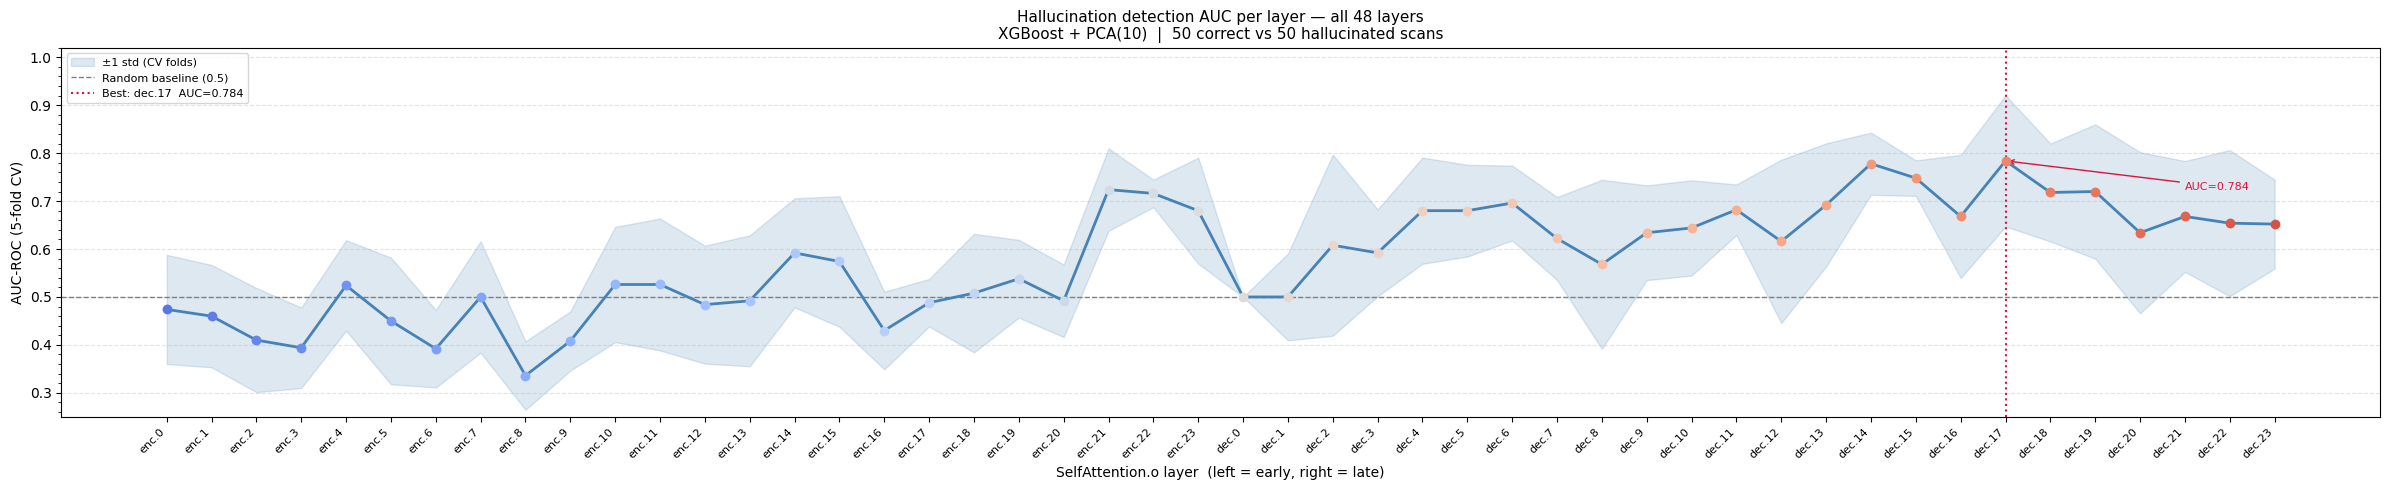

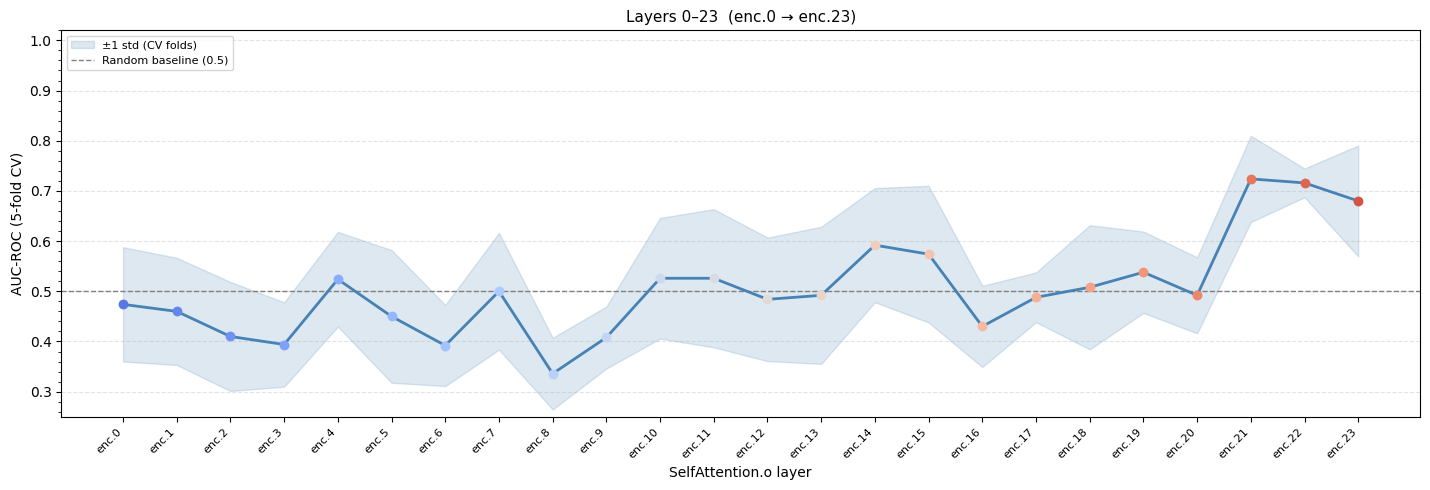

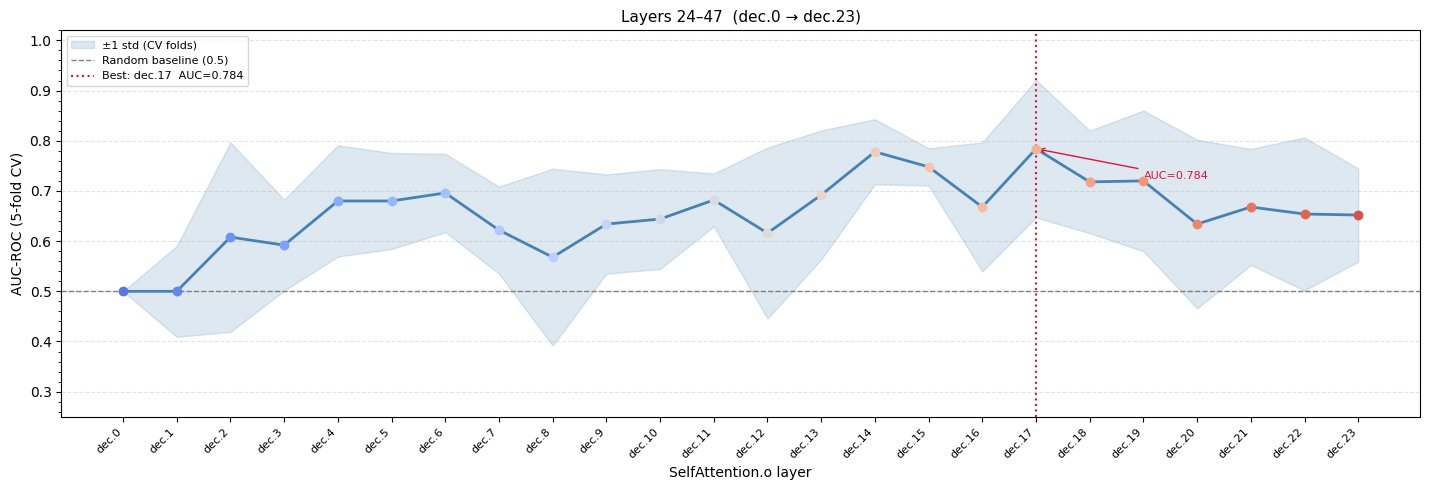

In [6]:
import matplotlib.patches as mpatches

def _layer_plot(ax, indices, aucs, auc_stds, layer_labels, best_idx, title):
    """Draw AUC-vs-layer onto ax for the given subset of layer indices."""
    x      = np.arange(len(indices))
    sub_aucs  = aucs[indices]
    sub_stds  = auc_stds[indices]
    sub_labels = [layer_labels[i] for i in indices]
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(x)))

    band = ax.fill_between(x, sub_aucs - sub_stds, sub_aucs + sub_stds,
                           alpha=0.18, color="steelblue", label="±1 std (CV folds)")
    ax.plot(x, sub_aucs, color="steelblue", linewidth=2, zorder=3)
    for xi, auc, c in zip(x, sub_aucs, colors):
        ax.scatter(xi, auc, color=c, s=50, zorder=4, linewidths=0)

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.5)")

    # Mark best layer if it falls in this slice
    if best_idx in indices:
        local_x = list(indices).index(best_idx)
        ax.axvline(local_x, color="crimson", linestyle=":", linewidth=1.5,
                   label=f"Best: {layer_labels[best_idx]}  AUC={aucs[best_idx]:.3f}")
        ax.annotate(
            f"AUC={aucs[best_idx]:.3f}",
            xy=(local_x, aucs[best_idx]),
            xytext=(local_x + max(1, len(indices) // 10), aucs[best_idx] - 0.06),
            arrowprops=dict(arrowstyle="->", color="crimson"),
            fontsize=8, color="crimson",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(sub_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("AUC-ROC (5-fold CV)")
    ax.set_ylim(0.25, 1.02)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(fontsize=8, loc="upper left")


all_idx = np.arange(len(layer_labels))
mid     = len(all_idx) // 2
first_half  = all_idx[:mid]
second_half = all_idx[mid:]

# ── Overview (all layers) ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, len(all_idx) * 0.5), 5))
_layer_plot(ax, all_idx, aucs, auc_stds, layer_labels, best_idx,
            f"Hallucination detection AUC per layer — all {len(all_idx)} layers\n"
            f"XGBoost + PCA({K_COMPONENTS})  |  {GROUP_SIZE} correct vs {GROUP_SIZE} hallucinated scans")
ax.set_xlabel("SelfAttention.o layer  (left = early, right = late)")
plt.tight_layout()
plt.show()

# ── First half ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, mid * 0.6), 5))
_layer_plot(ax, first_half, aucs, auc_stds, layer_labels, best_idx,
            f"Layers {first_half[0]}–{first_half[-1]}  ({layer_labels[first_half[0]]} → {layer_labels[first_half[-1]]})")
ax.set_xlabel("SelfAttention.o layer")
plt.tight_layout()
plt.show()

# ── Second half ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, (len(all_idx) - mid) * 0.6), 5))
_layer_plot(ax, second_half, aucs, auc_stds, layer_labels, best_idx,
            f"Layers {second_half[0]}–{second_half[-1]}  ({layer_labels[second_half[0]]} → {layer_labels[second_half[-1]]})")
ax.set_xlabel("SelfAttention.o layer")
plt.tight_layout()
plt.show()

## Cell 7 — ROC curve for the best layer

Uses `cross_val_predict` for honest out-of-fold probabilities at the layer
that achieved the highest AUC in Cell 5.

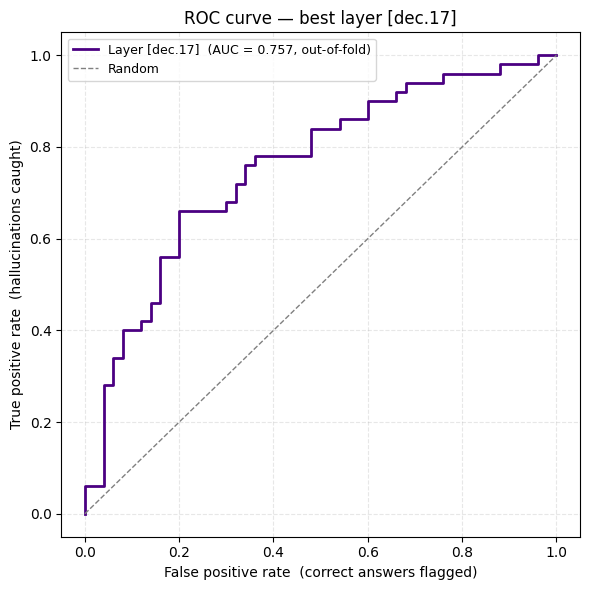

In [7]:
# Rebuild X/y for the best layer
vecs_c_best, _ = build_matrix(group_correct,      best_lid)
vecs_h_best, _ = build_matrix(group_hallucinated, best_lid,
                               expected_dim=vecs_c_best.shape[1])
X_best = np.vstack([vecs_c_best.numpy(), vecs_h_best.numpy()])
y_best = np.array([0] * len(vecs_c_best) + [1] * len(vecs_h_best))

pipe_best = Pipeline([
    ("pca", PCA(n_components=K_COMPONENTS, random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(
        n_estimators=100,
        verbosity=0,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    )),
])

y_prob = cross_val_predict(pipe_best, X_best, y_best,
                           cv=cv, method="predict_proba")[:, 1]
fpr, tpr, _ = roc_curve(y_best, y_prob)
auc_oof      = roc_auc_score(y_best, y_prob)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="indigo", linewidth=2,
        label=f"Layer [{best_label}]  (AUC = {auc_oof:.3f}, out-of-fold)")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random")
ax.set_xlabel("False positive rate  (correct answers flagged)")
ax.set_ylabel("True positive rate  (hallucinations caught)")
ax.set_title(f"ROC curve — best layer [{best_label}]")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 8 — Where does the signal first exceed chance?

Finds the earliest layer where AUC is meaningfully above 0.5 (threshold configurable),
and plots a zoomed view of the early layers to highlight the emergence point.

Signal first exceeds 0.60 at layer [21] enc.21
  AUC = 0.7240 ± 0.0859


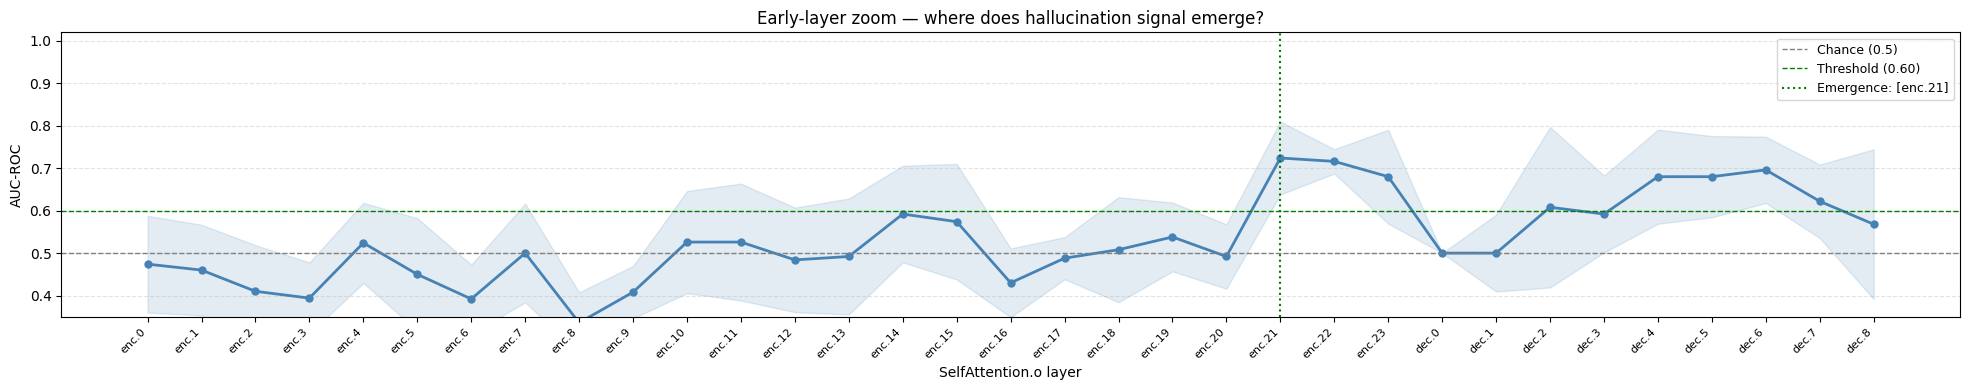

In [9]:
EMERGENCE_THRESHOLD = 0.60   # AUC above this is considered "meaningful signal"

emergence_idx = next(
    (i for i, a in enumerate(aucs) if a >= EMERGENCE_THRESHOLD),
    None
)

if emergence_idx is None:
    print(f"No layer exceeded AUC {EMERGENCE_THRESHOLD:.2f}")
else:
    print(f"Signal first exceeds {EMERGENCE_THRESHOLD:.2f} at layer [{emergence_idx}] {layer_labels[emergence_idx]}")
    print(f"  AUC = {aucs[emergence_idx]:.4f} ± {auc_stds[emergence_idx]:.4f}")

    # Zoom into early layers (up to emergence + a few more for context)
    zoom_end = min(len(aucs), emergence_idx + max(5, len(aucs) // 4))
    xz = np.arange(zoom_end)

    fig, ax = plt.subplots(figsize=(max(7, zoom_end * 0.6), 4))
    ax.fill_between(xz, aucs[:zoom_end] - auc_stds[:zoom_end],
                        aucs[:zoom_end] + auc_stds[:zoom_end],
                    alpha=0.15, color="steelblue")
    ax.plot(xz, aucs[:zoom_end], color="steelblue", linewidth=2, marker="o",
            markersize=5)
    ax.axhline(0.5, color="gray",   linestyle="--", linewidth=1, label="Chance (0.5)")
    ax.axhline(EMERGENCE_THRESHOLD, color="green", linestyle="--", linewidth=1,
               label=f"Threshold ({EMERGENCE_THRESHOLD:.2f})")
    ax.axvline(emergence_idx, color="green", linestyle=":", linewidth=1.5,
               label=f"Emergence: [{layer_labels[emergence_idx]}]")
    ax.set_xticks(xz)
    ax.set_xticklabels(layer_labels[:zoom_end], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("AUC-ROC")
    ax.set_xlabel("SelfAttention.o layer")
    ax.set_ylim(0.35, 1.02)
    ax.set_title("Early-layer zoom — where does hallucination signal emerge?", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()